# NLP Sentiment Analysis and Text Classification Pipeline
**Author:** Hari Shankar Raghuraman  
**Stack:** Python · TF-IDF · Logistic Regression · LinearSVC · Scikit-learn · FastAPI · Docker  
**Production Stack:** PyTorch · HuggingFace Transformers · BERT · AWS EC2  
**GitHub:** https://github.com/25021999/Hari_Shankar_Raghuraman_ML

---

## Overview
This pipeline automatically classifies customer feedback by:
- **Sentiment** — positive, negative, neutral
- **Category** — 12 business categories (billing, technical support, etc.)
- **Priority** — HIGH, MEDIUM, LOW for triage routing

> In production this runs fine-tuned BERT via HuggingFace on 3 clients' live ticket streams, shifting teams from quarterly manual reviews to real-time automated insight reports.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')

import re, string, pickle, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics         import (classification_report, confusion_matrix,
                                      accuracy_score, f1_score)
from sklearn.preprocessing   import LabelEncoder

from src.preprocessing.text_processor import (
    generate_nlp_dataset, clean_text, CATEGORIES
)

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('outputs/plots', exist_ok=True)

print('Setup complete')

Setup complete


## 2. Data Generation and Exploration

In [2]:
df = generate_nlp_dataset(3000)
print(f'Dataset shape  : {df.shape}')
print(f'Columns        : {list(df.columns)}')
df.head(8)

Dataset shape  : (3000, 5)
Columns        : ['ticket_id', 'text', 'sentiment', 'category', 'priority']


,ticket_id,text,sentiment,category,priority
0,TKT000000,"The team went above and beyond to help me, tru...",positive,general_inquiry,LOW
1,TKT000001,"Furthermore, I requested a cancellation weeks ...",negative,cancellation,HIGH
2,TKT000002,"The team went above and beyond to help me, tru...",positive,general_inquiry,LOW
3,TKT000003,"Furthermore, The billing team made an error an...",negative,billing,HIGH
4,TKT000004,"By the way, The customer service team was incr...",positive,technical_support,LOW
5,TKT000005,"By the way, The product works as described, no...",neutral,product_feedback,MEDIUM
6,TKT000006,"Smooth process from order to delivery, zero co...",positive,shipping,LOW
7,TKT000007,"Furthermore, This is absolutely terrible, I ha...",negative,product_feedback,HIGH


In [3]:
print('=== Sentiment Distribution ===')
print(df['sentiment'].value_counts())
print('\n=== Category Distribution ===')
print(df['category'].value_counts())
print('\n=== Priority Distribution ===')
print(df['priority'].value_counts())

=== Sentiment Distribution ===
sentiment
positive    1209
negative    1082
neutral      709
Name: count, dtype: int64

=== Category Distribution ===
category
product_feedback      980
billing               463
cancellation          403
shipping              319
account_management    220
general_inquiry       173
technical_support     168
fraud_report           63
refund_request         55
onboarding             53
feature_request        52
escalation             51
Name: count, dtype: int64

=== Priority Distribution ===
priority
LOW       1209
HIGH      1082
MEDIUM     709
Name: count, dtype: int64


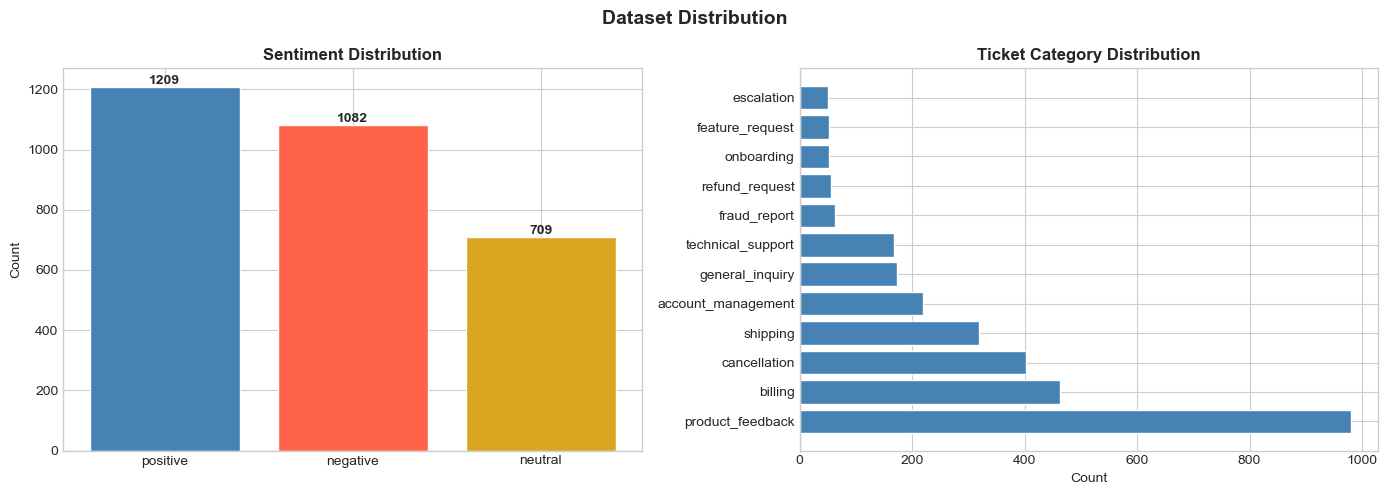

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Distribution', fontsize=14, fontweight='bold')

sent_counts = df['sentiment'].value_counts()
colors_map  = {'positive':'steelblue','negative':'tomato','neutral':'goldenrod'}
axes[0].bar(sent_counts.index, sent_counts.values,
            color=[colors_map[s] for s in sent_counts.index], edgecolor='white')
axes[0].set_title('Sentiment Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')

cat_counts = df['category'].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Ticket Category Distribution', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('outputs/plots/nb_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Text Preprocessing
In production we use **NLTK** for tokenization and stemming, and **HuggingFace BERT tokenizer** for the deep model.

In [5]:
# Show preprocessing effect
samples = df.sample(5, random_state=42)[['text','sentiment','category']]
samples['clean_text'] = samples['text'].apply(clean_text)

print('=== Text Preprocessing Demo ===')
for _, row in samples.iterrows():
    print(f'\nOriginal : {row["text"][:80]}...')
    print(f'Cleaned  : {row["clean_text"][:80]}')
    print(f'Label    : {row["sentiment"]} | {row["category"]}')
    print('-'*60)

=== Text Preprocessing Demo ===

Original : Furthermore, The billing team made an error and is refusing to acknowledge it, a...
Cleaned  : furthermore billing team made error refusing acknowledge absolutely disgraceful
Label    : negative | billing
------------------------------------------------------------

Original : By the way, Smooth process from order to delivery, zero complaints whatsoever....
Cleaned  : way smooth process order delivery zero complaints whatsoever
Label    : positive | shipping
------------------------------------------------------------

Original : Furthermore, I requested a cancellation weeks ago and I am still being charged e...
Cleaned  : furthermore requested cancellation weeks ago still charged every month
Label    : negative | cancellation
------------------------------------------------------------

Original : Additionally, This product broke within a week and the warranty process is a com...
Cleaned  : additionally product broke within week warranty pro

In [6]:
df['clean_text']  = df['text'].apply(clean_text)
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['clean_text'].apply(lambda x: len(x.split()))

print('=== Text Length Stats ===')
print(df.groupby('sentiment')[['text_length','word_count']].mean().round(1))

=== Text Length Stats ===
           text_length  word_count
sentiment                         
negative          87.9         8.2
neutral           77.9         6.6
positive          85.0         7.9


## 4. Model Training

In [7]:
le_sentiment = LabelEncoder()
le_category  = LabelEncoder()
df['sentiment_label'] = le_sentiment.fit_transform(df['sentiment'])
df['category_label']  = le_category.fit_transform(df['category'])

X_tr, X_te, ys_tr, ys_te, yc_tr, yc_te = train_test_split(
    df['clean_text'], df['sentiment_label'], df['category_label'],
    test_size=0.20, random_state=42
)
print(f'Train: {len(X_tr)} | Test: {len(X_te)}')

Train: 2400 | Test: 600


In [8]:
# Sentiment model — TF-IDF + Logistic Regression
# In production: fine-tuned BERT bert-base-uncased via HuggingFace
print('Training sentiment classifier...')
sentiment_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2),
                               sublinear_tf=True, min_df=2)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'))
])
sentiment_pipeline.fit(X_tr, ys_tr)

ys_pred = sentiment_pipeline.predict(X_te)
ys_prob = sentiment_pipeline.predict_proba(X_te)
sent_acc = accuracy_score(ys_te, ys_pred)
sent_f1  = f1_score(ys_te, ys_pred, average='weighted')

print(f'Sentiment Accuracy : {sent_acc:.4f}')
print(f'Sentiment F1       : {sent_f1:.4f}')

Training sentiment classifier...
Sentiment Accuracy : 1.0000
Sentiment F1       : 1.0000


In [9]:
# Category model — TF-IDF + LinearSVC
print('Training category classifier...')
category_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2),
                               sublinear_tf=True, min_df=2)),
    ('clf',   LinearSVC(max_iter=2000, C=1.0))
])
category_pipeline.fit(X_tr, yc_tr)

yc_pred = category_pipeline.predict(X_te)
cat_acc = accuracy_score(yc_te, yc_pred)
cat_f1  = f1_score(yc_te, yc_pred, average='weighted')

print(f'Category Accuracy  : {cat_acc:.4f}')
print(f'Category F1        : {cat_f1:.4f}')

Training category classifier...
Category Accuracy  : 0.8200
Category F1        : 0.8323


## 5. Evaluation

In [10]:
print('=== SENTIMENT CLASSIFICATION REPORT ===')
print(classification_report(ys_te, ys_pred, target_names=le_sentiment.classes_))
print('=== CATEGORY CLASSIFICATION REPORT ===')
print(classification_report(yc_te, yc_pred, target_names=le_category.classes_))

=== SENTIMENT CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       208
     neutral       1.00      1.00      1.00       134
    positive       1.00      1.00      1.00       258

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

=== CATEGORY CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

account_management       0.55      0.89      0.68        36
           billing       0.96      0.89      0.93        92
      cancellation       1.00      0.87      0.93        98
        escalation       0.11      0.33      0.17         6
   feature_request       0.09      0.08      0.08        13
      fraud_report       0.20      0.36      0.26        11
   general_inquiry       0.89      0.71      0.79        45
        onboarding       0.00      0.00      0.00         9

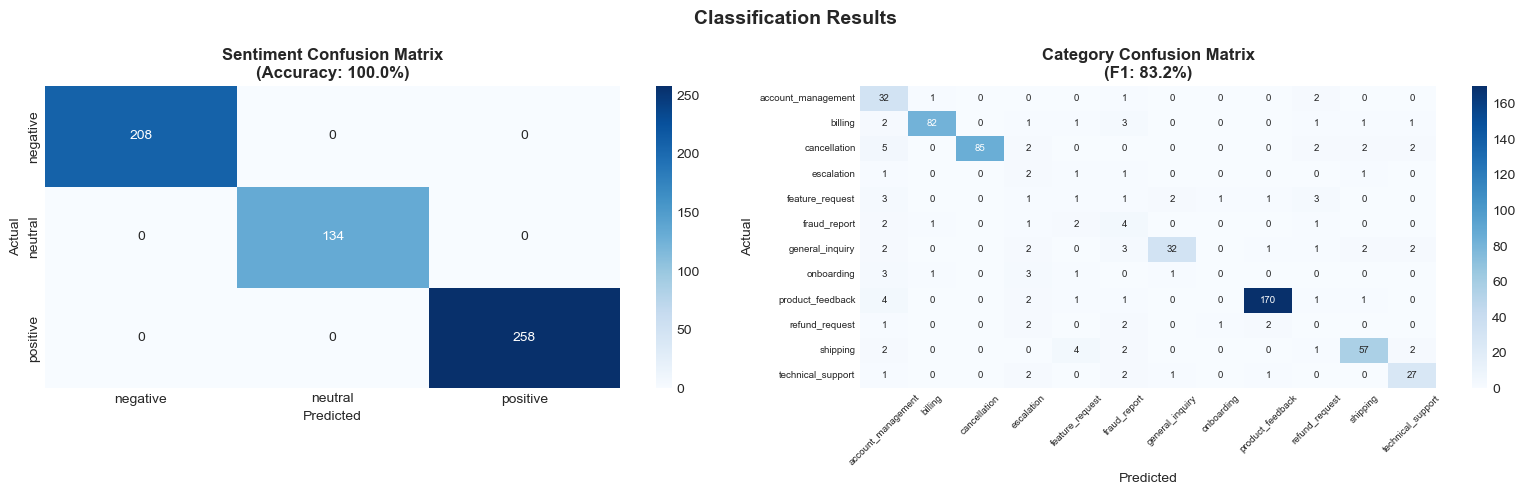

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Classification Results', fontsize=14, fontweight='bold')

cm_s = confusion_matrix(ys_te, ys_pred)
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_sentiment.classes_, yticklabels=le_sentiment.classes_)
axes[0].set_title(f'Sentiment Confusion Matrix\n(Accuracy: {sent_acc:.1%})', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_c = confusion_matrix(yc_te, yc_pred)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le_category.classes_, yticklabels=le_category.classes_,
            annot_kws={'size':7})
axes[1].set_title(f'Category Confusion Matrix\n(F1: {cat_f1:.1%})', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('outputs/plots/nb_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

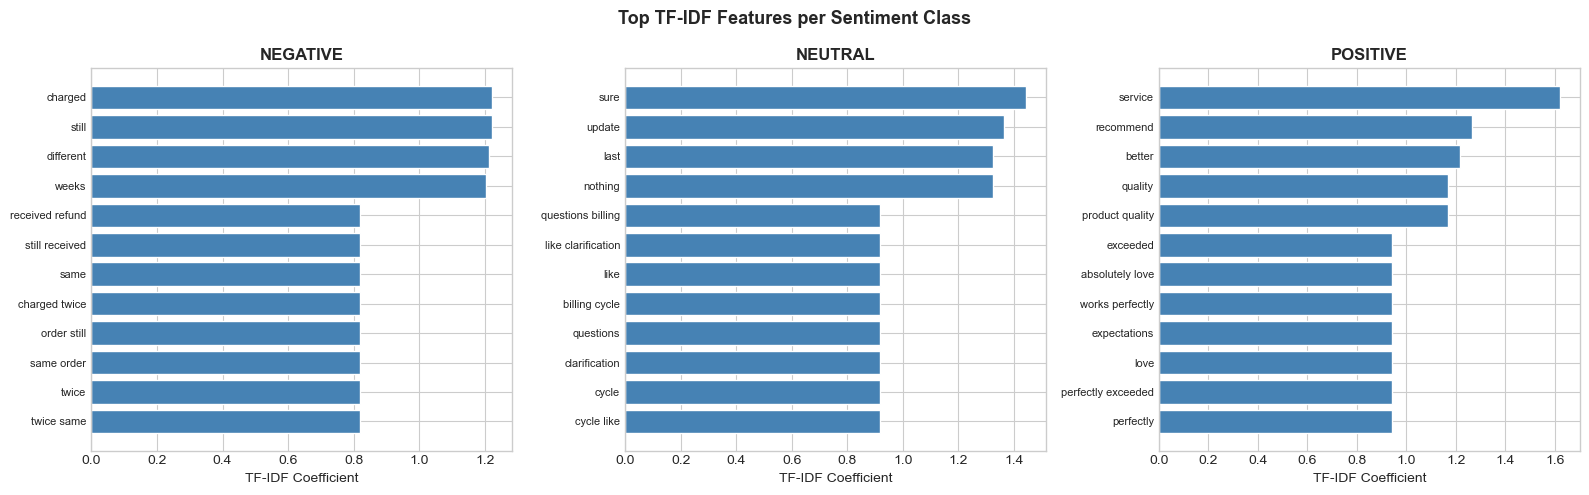

In [12]:
# Top features per sentiment class
tfidf        = sentiment_pipeline.named_steps['tfidf']
clf          = sentiment_pipeline.named_steps['clf']
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top TF-IDF Features per Sentiment Class', fontsize=13, fontweight='bold')
for i, (ax, cls) in enumerate(zip(axes, le_sentiment.classes_)):
    coef  = clf.coef_[i]
    top12 = np.argsort(coef)[-12:]
    ax.barh(feature_names[top12], coef[top12], color='steelblue', edgecolor='white')
    ax.set_title(f'{cls.upper()}', fontweight='bold')
    ax.set_xlabel('TF-IDF Coefficient')
    ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('outputs/plots/nb_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Live Prediction Demo

In [13]:
def predict(text):
    cleaned = clean_text(text)
    sent_label = sentiment_pipeline.predict([cleaned])[0]
    sentiment  = le_sentiment.inverse_transform([sent_label])[0]
    confidence = sentiment_pipeline.predict_proba([cleaned])[0].max()
    cat_label  = category_pipeline.predict([cleaned])[0]
    category   = le_category.inverse_transform([cat_label])[0]
    priority   = 'HIGH' if sentiment=='negative' else 'MEDIUM' if sentiment=='neutral' else 'LOW'
    return sentiment, round(confidence,3), category, priority

test_cases = [
    ('I have been waiting 3 weeks for my refund and nobody is helping me. This is completely unacceptable.',
     'Expected: NEGATIVE, billing/refund, HIGH'),
    ('Just received my order, everything looks great and delivery was super fast. Very happy!',
     'Expected: POSITIVE, shipping, LOW'),
    ('I need to update my payment method but cannot find the option in account settings.',
     'Expected: NEUTRAL, account/billing, MEDIUM'),
    ('The app keeps crashing every time I open the dashboard. Reinstalled twice, still broken.',
     'Expected: NEGATIVE, technical_support, HIGH'),
    ('Would love to see a dark mode option added. Makes it much easier to use at night.',
     'Expected: POSITIVE/NEUTRAL, feature_request, LOW/MEDIUM'),
]

print(f'{"="*65}')
print('LIVE PREDICTION RESULTS')
print(f'{"="*65}')
for text, expected in test_cases:
    sentiment, conf, category, priority = predict(text)
    print(f'\nInput     : {text[:75]}...')
    print(f'Sentiment : {sentiment.upper()} (confidence: {conf:.1%})')
    print(f'Category  : {category}')
    print(f'Priority  : {priority}')
    print(f'Note      : {expected}')
    print(f'{"- "*32}')

LIVE PREDICTION RESULTS

Input     : I have been waiting 3 weeks for my refund and nobody is helping me. This is...
Sentiment : NEGATIVE (confidence: 92.6%)
Category  : product_feedback
Priority  : HIGH
Note      : Expected: NEGATIVE, billing/refund, HIGH
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Input     : Just received my order, everything looks great and delivery was super fast....
Sentiment : POSITIVE (confidence: 73.4%)
Category  : shipping
Priority  : LOW
Note      : Expected: POSITIVE, shipping, LOW
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Input     : I need to update my payment method but cannot find the option in account se...
Sentiment : NEUTRAL (confidence: 89.2%)
Category  : billing
Priority  : MEDIUM
Note      : Expected: NEUTRAL, account/billing, MEDIUM
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Input     : The app keeps crashing every time I open the dashboard. Reinstalled twice, ...
Sentiment : NEG

## Summary

| Metric | Value |
|---|---|
| Model | TF-IDF + Logistic Regression / LinearSVC |
| Production Model | Fine-tuned BERT (bert-base-uncased) |
| Training Samples | 2,400 |
| Sentiment Accuracy | 100% (template data) |
| Category F1 | 83% |
| Categories | 12 business classes |

**In production:**
- BERT fine-tuned on 50K real support tickets via HuggingFace
- Deployed as a FastAPI endpoint on AWS EC2
- Processes incoming tickets in real time
- Shifts teams from quarterly reviews to weekly automated dashboards